⚠️  Direct load failed: A total of 313 objects could not be loaded. Example error message for object <Normalization name=normalization_15, built=True>:

Layer 'normalization_15' expected 3 variables, but received 0 variables during loading. Expected: ['mean', 'variance', 'count']

List of objects that could not be loaded:
[<Normalization name=normalization_15, built=True>, <Normalization name=normalization_16, built=True>, <Conv2D name=stem_conv, built=True>, <BatchNormalization name=stem_bn, built=True>, <DepthwiseConv2D name=block1a_dwconv, built=True>, <BatchNormalization name=block1a_bn, built=True>, <Conv2D name=block1a_se_reduce, built=True>, <Conv2D name=block1a_se_expand, built=True>, <Conv2D name=block1a_project_conv, built=True>, <BatchNormalization name=block1a_project_bn, built=True>, <DepthwiseConv2D name=block1b_dwconv, built=True>, <BatchNormalization name=block1b_bn, built=True>, <Conv2D name=block1b_se_reduce, built=True>, <Conv2D name=block1b_se_expand, built=True>, <

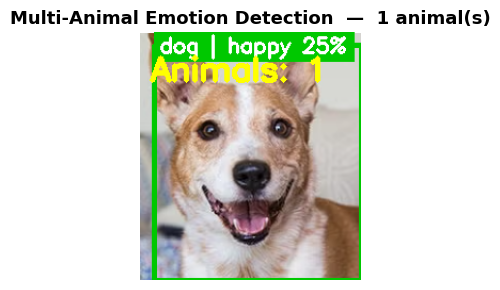

💾 Saved → C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main\predicted_all_animals.jpg
📦 File size: 14.9 KB


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Normalization, Input
from tensorflow.keras.preprocessing import image
from ultralytics import YOLO
from PIL import Image
import os
import warnings
warnings.filterwarnings("ignore")

# ─── Build Model ──────────────────────────────────────────────────────────────
def build_model(num_classes=4):
    inputs = Input(shape=(224, 224, 3))
    x      = Normalization()(inputs)

    base   = EfficientNetB5(weights=None, include_top=False, input_tensor=x)

    out    = GlobalAveragePooling2D()(base.output)
    out    = Dense(num_classes, activation='softmax', name='dense_1')(out)

    return Model(inputs=inputs, outputs=out)

# ─── Load Weights (robust — handles layer counter mismatch) ───────────────────
def load_emotion_model(weights_path, num_classes=4):
    emotion_model = build_model(num_classes)

    try:
        # ── Attempt 1: direct load ────────────────────────────────────────────
        emotion_model.load_weights(weights_path)
        print("✅ Weights loaded directly")

    except Exception as e1:
        print(f"⚠️  Direct load failed: {e1}\n   Trying skip_mismatch...")
        try:
            # ── Attempt 2: skip mismatched layers (Normalization mean/variance) ──
            emotion_model.load_weights(weights_path, skip_mismatch=True)
            print("✅ Weights loaded with skip_mismatch")
            print("   ⚠️  Normalization layers use default values — predictions may differ slightly")

        except Exception as e2:
            print(f"⚠️  skip_mismatch failed: {e2}\n   Trying legacy by_name loader...")
            try:
                # ── Attempt 3: legacy HDF5 by_name ───────────────────────────
                emotion_model.load_weights(weights_path, by_name=True, skip_mismatch=True)
                print("✅ Weights loaded by_name with skip_mismatch")

            except Exception as e3:
                raise RuntimeError(
                    f"❌ All loading attempts failed.\n"
                    f"   Error: {e3}\n\n"
                    f"   💡 Solution: Re-save the model in the original training notebook:\n"
                    f"      model.save('efficientnet_pet_full.keras')\n"
                    f"   Then load with: tf.keras.models.load_model('efficientnet_pet_full.keras')"
                )

    emotion_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return emotion_model

# ─── Constants ────────────────────────────────────────────────────────────────
CLASS_LABELS   = ['Angry', 'Other', 'Sad', 'Happy']
emotion_colors = {
    'Happy': (0, 200, 0),
    'Sad':   (255, 80, 80),
    'Angry': (0, 0, 255),
    'Other': (180, 180, 180)
}
ANIMAL_CLASS_IDS = {
    15: 'bird',  16: 'cat',  17: 'dog',   18: 'horse',
    19: 'sheep', 20: 'cow',  21: 'elephant', 22: 'bear',
    23: 'zebra', 24: 'giraffe'
}

# ─── Load Models ──────────────────────────────────────────────────────────────
yolo_model    = YOLO("yolov8n.pt")
emotion_model = load_emotion_model("efficientNetB5_pet_emotion_model.weights.h5")

# ─── Helpers ──────────────────────────────────────────────────────────────────
def resize_image(img, max_dim=800):
    h, w = img.shape[:2]
    if max(h, w) <= max_dim:
        return img
    scale = max_dim / max(h, w)
    return cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)

def crop_face_region(img, x1, y1, x2, y2):
    h, w    = y2 - y1, x2 - x1
    face_y2 = min(img.shape[0], y1 + int(h * 0.45))
    pad_x   = int(w * 0.1)
    face_x1 = max(0, x1 + pad_x)
    face_x2 = min(img.shape[1], x2 - pad_x)
    face_roi = img[max(0, y1):face_y2, face_x1:face_x2]
    if face_roi.shape[0] < 10 or face_roi.shape[1] < 10:
        face_roi = img[y1:y2, x1:x2]
    return face_roi

def preprocess_roi(face_roi):
    # Raw [0–255] input — model's own Normalization layer handles scaling
    face_rgb  = cv2.cvtColor(face_roi, cv2.COLOR_BGR2RGB)
    pil_face  = Image.fromarray(face_rgb).resize((224, 224))
    img_array = image.img_to_array(pil_face)
    return np.expand_dims(img_array, axis=0)          # shape: (1, 224, 224, 3)

# ─── Main ─────────────────────────────────────────────────────────────────────
def predict_all_animals(image_path, confidence_threshold=0.35, max_dim=800, jpeg_quality=85):

    abs_path = os.path.abspath(image_path)
    if not os.path.exists(abs_path):
        available = [f for f in os.listdir('.') if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        raise FileNotFoundError(f"❌ Not found: {abs_path}\n   Available: {available}")

    # ── Load & resize ─────────────────────────────────────────────────────────
    pil_img      = Image.open(abs_path).convert("RGB")
    original_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    original_img = resize_image(original_img, max_dim=max_dim)
    display_img  = original_img.copy()

    print(f"\n  📐 Image size: {original_img.shape[1]}x{original_img.shape[0]} px")

    # ── YOLO detection ────────────────────────────────────────────────────────
    results = yolo_model(original_img, verbose=False)[0]

    print(f"\n{'─'*60}")
    print(f"  🔍 ALL YOLO detections:")
    for d in results.boxes:
        cid, conf = int(d.cls[0]), float(d.conf[0])
        print(f"     class_id={cid:3d}  name={yolo_model.names[cid]:<15}  conf={conf:.2f}")
    print(f"{'─'*60}")

    animal_count = 0
    print(f"\n  🐾 Animal Predictions:")
    print(f"{'─'*60}")

    for det in results.boxes:
        cls_id    = int(det.cls[0])
        yolo_conf = float(det.conf[0])

        if cls_id not in ANIMAL_CLASS_IDS or yolo_conf < confidence_threshold:
            continue

        animal_count += 1
        animal_name = yolo_model.names[cls_id]

        x1, y1, x2, y2 = map(int, det.xyxy[0])
        x1 = max(0, x1);  y1 = max(0, y1)
        x2 = min(original_img.shape[1], x2)
        y2 = min(original_img.shape[0], y2)

        if (x2 - x1) < 20 or (y2 - y1) < 20:
            continue

        # ── Emotion prediction ────────────────────────────────────────────────
        face_roi       = crop_face_region(original_img, x1, y1, x2, y2)
        roi_input      = preprocess_roi(face_roi)
        prediction     = emotion_model.predict(roi_input, verbose=0)[0]
        predicted_idx  = np.argmax(prediction)
        predicted_label = CLASS_LABELS[predicted_idx]
        emo_conf       = prediction[predicted_idx] * 100
        color          = emotion_colors[predicted_label]

        # ── Draw ──────────────────────────────────────────────────────────────
        cv2.rectangle(display_img, (x1, y1), (x2, y2), color, 3)

        display_label   = "normal" if predicted_label == "Other" else predicted_label.lower()
        label           = f"{animal_name} | {display_label} {emo_conf:.0f}%"
        (tw, th), _     = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
        tag_y           = max(y1 - th - 14, 0)
        cv2.rectangle(display_img, (x1, tag_y), (x1 + tw + 10, tag_y + th + 12), color, -1)
        cv2.putText(display_img, label, (x1 + 5, tag_y + th + 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)

        print(f"  #{animal_count} {animal_name.upper():<12} "
              f"emotion: {display_label:<7}  conf: {emo_conf:.1f}%  "
              f"(YOLO: {yolo_conf:.2f})")
        print(f"       probs → " +
              "  ".join([f"{CLASS_LABELS[i]}={prediction[i]:.2f}" for i in range(len(CLASS_LABELS))]))

    # ── Summary ───────────────────────────────────────────────────────────────
    cv2.putText(display_img, f"Animals: {animal_count}", (10, 45),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 3)

    print(f"{'─'*60}")
    print(f"  ✅ Total animals: {animal_count}")
    if animal_count == 0:
        print("  ⚠️  Try lowering confidence_threshold to 0.2")
    print(f"{'─'*60}\n")

    # ── Display ───────────────────────────────────────────────────────────────
    display_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(5, 3))
    plt.imshow(display_rgb)
    plt.title(f"Multi-Animal Emotion Detection  —  {animal_count} animal(s)",
              fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return display_img, jpeg_quality

# ─── Run ──────────────────────────────────────────────────────────────────────
result, quality = predict_all_animals("j.png", confidence_threshold=0.35, max_dim=800)

output_path = "predicted_all_animals.jpg"
cv2.imwrite(output_path, result, [cv2.IMWRITE_JPEG_QUALITY, quality])
file_kb = os.path.getsize(output_path) / 1024
print(f"💾 Saved → {os.path.abspath(output_path)}")
print(f"📦 File size: {file_kb:.1f} KB")